In [1]:
import pandas as pd
import numpy as np

master = pd.read_csv(
    "../data/master_dataset.csv"
)

master["timestamp"] = pd.to_datetime(
    master["timestamp"]
)

In [2]:
master = master.dropna()
print(master.shape)

(2128152, 24)


# Model and Feature 1

In [4]:
features = [
    "grid",

    "hour",
    "dayofweek",
    "weekend",

    "fast_count",
    "slow_count",
    "area",
    "CBD",

    "occ_lag_1",
    "occ_lag_12",
    "occ_lag_24",

    "rolling_mean_12",
    "rolling_mean_24"
]

target = "occupancy"

In [5]:
X = master[features]

y = master[target]

In [6]:
# Train Test Split

split_index = int(
    len(master) * 0.8
)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Random Forest

In [7]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train,y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [8]:

pred = rf.predict(X_test)

In [9]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [10]:
mae = mean_absolute_error(
    y_test,
    pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

r2 = r2_score(
    y_test,
    pred
)

In [11]:
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.4854439769714244
RMSE: 2.598458811605247
R²  : 0.9897605526533599


In [12]:
sample = 1000

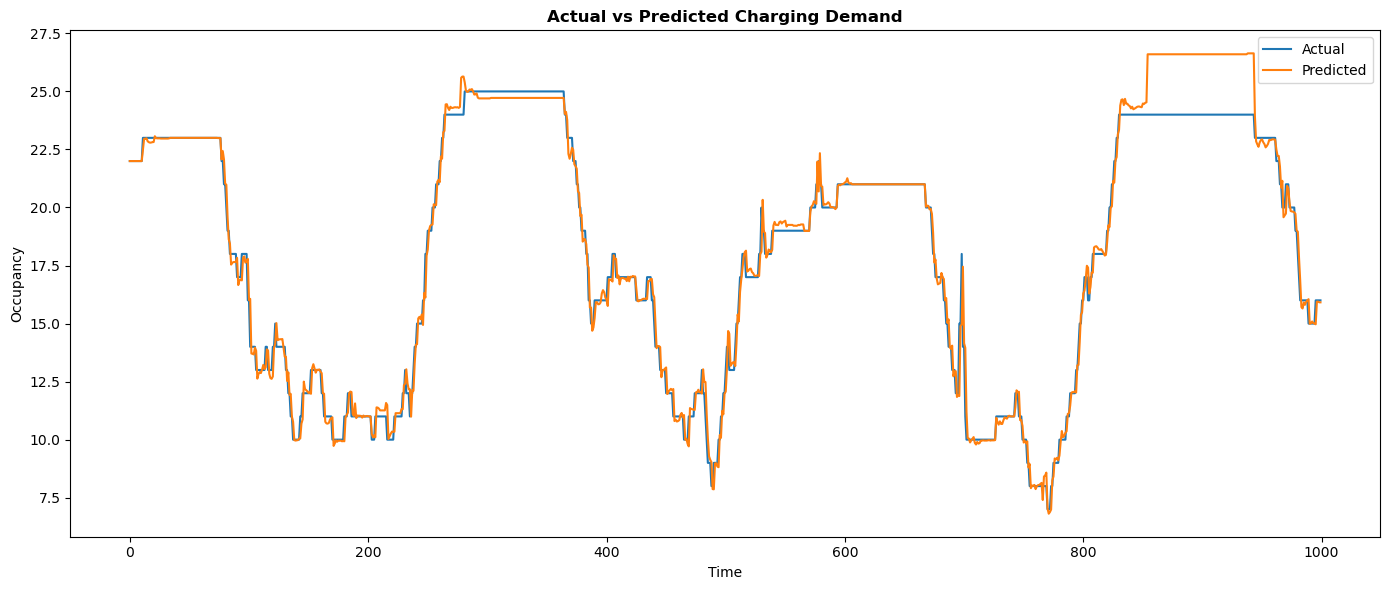

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))

plt.plot(
    y_test.iloc[:sample].values,
    label="Actual"
)

plt.plot(
    pred[:sample],
    label="Predicted"
)

plt.title(
    "Actual vs Predicted Charging Demand",
    fontweight="bold"
)

plt.xlabel("Time")

plt.ylabel("Occupancy")

plt.legend()

plt.tight_layout()

plt.show()

In [15]:
importance = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(
    ascending=False
)

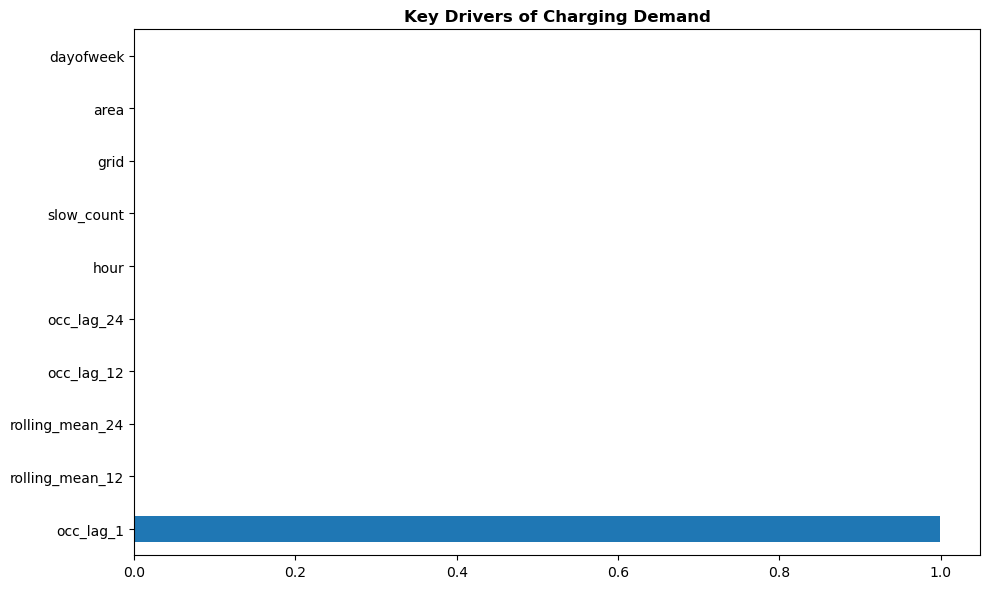

In [16]:
plt.figure(figsize=(10,6))

importance.head(10).plot(
    kind="barh"
)

plt.title(
    "Key Drivers of Charging Demand",
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [17]:
importance.sort_values(
    ascending=False
)

occ_lag_1          0.998924
rolling_mean_12    0.000299
rolling_mean_24    0.000174
occ_lag_12         0.000116
occ_lag_24         0.000108
hour               0.000098
slow_count         0.000063
grid               0.000055
area               0.000053
dayofweek          0.000053
fast_count         0.000041
weekend            0.000009
CBD                0.000006
dtype: float64

# Model and feature 2

In [20]:
features_v2 = [
    "grid",

    "hour",
    "dayofweek",
    "weekend",

    "fast_count",
    "slow_count",
    "area",
    "CBD",

    "occ_lag_12",
    "occ_lag_24",

    "rolling_mean_12",
    "rolling_mean_24"
]

In [21]:
X_v2 = master[features_v2]
y_v2 = master["occupancy"]

In [22]:
# Train Test Split

split_index = int(
    len(master) * 0.8
)

X_v2_train = X_v2.iloc[:split_index]
X_v2_test = X_v2.iloc[split_index:]

y_v2__train = y_v2.iloc[:split_index]
y_v2_test = y_v2.iloc[split_index:]

In [23]:
from sklearn.ensemble import RandomForestRegressor

rf2 = RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)

rf2.fit(X_v2_train,y_v2__train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [24]:
pred2 = rf2.predict(X_v2_test)

from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

mae2 = mean_absolute_error(y_v2_test,pred2)
rmse2 = np.sqrt(mean_squared_error(y_v2_test,pred2))
r2_2 = r2_score(y_v2_test,pred2)

In [25]:
print("MAE :", mae2)
print("RMSE:", rmse2)
print("R² :", r2_2)

MAE : 0.961064833234585
RMSE: 3.511492192893268
R² : 0.9813005747943173


In [26]:
importance2 = pd.Series(
    rf2.feature_importances_,
    index=features_v2
).sort_values(
    ascending=False
)

print(importance2)

rolling_mean_12    0.992520
occ_lag_12         0.003354
hour               0.000859
rolling_mean_24    0.000815
occ_lag_24         0.000598
slow_count         0.000456
grid               0.000344
area               0.000341
fast_count         0.000320
dayofweek          0.000318
weekend            0.000047
CBD                0.000029
dtype: float64


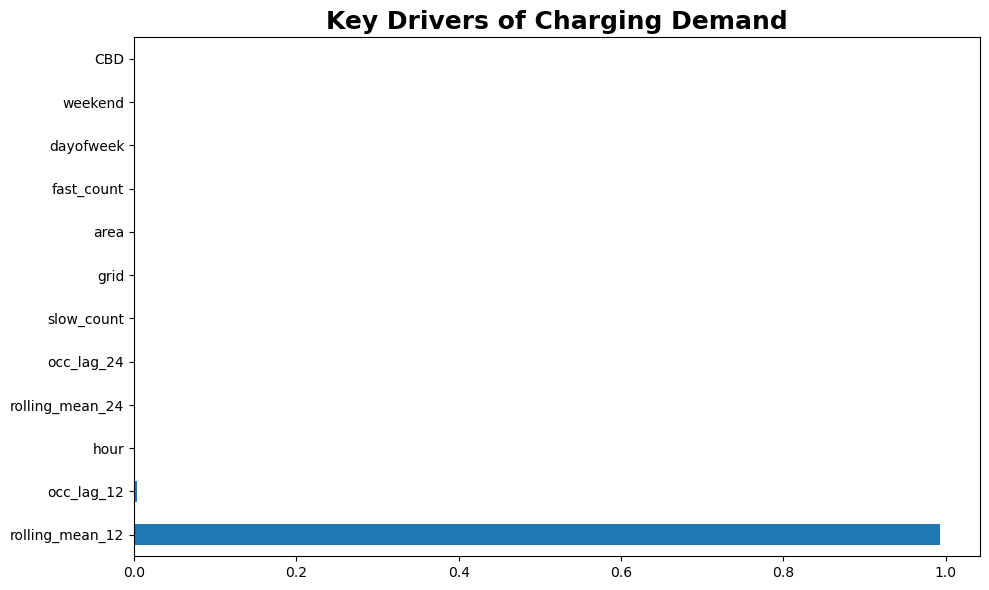

In [27]:
plt.figure(figsize=(10,6))

importance2.plot(
    kind="barh"
)

plt.title(
    "Key Drivers of Charging Demand",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# Prediction Column

In [28]:
master_clean = master.dropna().copy()

master_clean["predicted_occupancy"] = rf2.predict(master_clean[features_v2])

In [30]:
master_clean[["occupancy","predicted_occupancy"]].head()

,occupancy,predicted_occupancy
0,12,12.0
1,12,12.0
2,12,12.0
3,12,12.0
4,12,12.0


# Utilisation


In [33]:
print(master_clean["occupancy"].describe())

count    2.128152e+06
mean     2.189292e+01
std      2.478901e+01
min      0.000000e+00
25%      5.000000e+00
50%      1.300000e+01
75%      3.000000e+01
max      2.200000e+02
Name: occupancy, dtype: float64


In [34]:
print(master_clean["occupancy"].max())

220


In [35]:
print(master_clean.columns.tolist())

['timestamp', 'grid', 'occupancy', 'duration', 'num', 'count', 'fast_count', 'slow_count', 'area', 'lon', 'la', 'CBD', 'dynamic_pricing', 'time_step', 'hour', 'dayofweek', 'month', 'weekend', 'utilization', 'occ_lag_1', 'occ_lag_12', 'occ_lag_24', 'rolling_mean_12', 'rolling_mean_24', 'predicted_occupancy']


In [37]:
print(master_clean[["count","fast_count","slow_count"]].head(20))

    count  fast_count  slow_count
0      30           3          27
1      30           3          27
2      30           3          27
3      30           3          27
4      30           3          27
5      30           3          27
6      30           3          27
7      30           3          27
8      30           3          27
9      30           3          27
10     30           3          27
11     30           3          27
12     30           3          27
13     30           3          27
14     30           3          27
15     30           3          27
16     30           3          27
17     30           3          27
18     30           3          27
19     30           3          27


In [38]:
master_clean["utilization"] = (
    master_clean["predicted_occupancy"]
    /
    master_clean["count"]
)

In [39]:
master_clean["utilization"].describe()

count    2.128152e+06
mean     2.804112e-01
std      1.749598e-01
min      0.000000e+00
25%      1.531232e-01
50%      2.500000e-01
75%      3.772826e-01
max      1.190000e+00
Name: utilization, dtype: float64

## Create pricing tier

In [72]:
import numpy as np

master_clean["price_multiplier"] = np.select(
    [
        master_clean["utilization"] < 0.30,

        (master_clean["utilization"] >= 0.30)
        &
        (master_clean["utilization"] <= 0.80),

        master_clean["utilization"] > 0.80
    ],
    [
        1.0,
        1.25,
        1.50
    ],
    default=1.0
)

In [73]:
BASE_PRICE = 10

master_clean["dynamic_price"] = (
    BASE_PRICE
    *
    master_clean["price_multiplier"]
)

In [74]:
master_clean[
    [
        "utilization",
        "price_multiplier",
        "dynamic_price"
    ]
].head(20)

,utilization,price_multiplier,dynamic_price
0,0.4,1.25,12.5
1,0.4,1.25,12.5
2,0.4,1.25,12.5
3,0.4,1.25,12.5
4,0.4,1.25,12.5
5,0.4,1.25,12.5
6,0.4,1.25,12.5
7,0.4,1.25,12.5
8,0.4,1.25,12.5
9,0.4,1.25,12.5


In [75]:
master_clean["price_multiplier"].value_counts()

price_multiplier
1.00    1300204
1.25     807237
1.50      20711
Name: count, dtype: int64

Mostly underutilized stations. 
Few highly congested stations

# Revenue Comparison with price elasticity

In [76]:
# Revenue = Price × Occupancy

# Base Revenue
BASE_PRICE = 10
master_clean["baseline_revenue"] = (BASE_PRICE* master_clean["occupancy"])

# Dynamic Revenue
master_clean["dynamic_revenue"] = (master_clean["dynamic_price"] * master_clean["occupancy"])


In [77]:
# Total Revenue
baseline_total = (master_clean["baseline_revenue"].sum())

dynamic_total = (master_clean["dynamic_revenue"].sum())

improvement_pct = ((dynamic_total - baseline_total) / baseline_total * 100)

print("Baseline Revenue :", baseline_total)
print("Dynamic Revenue  :", dynamic_total)
print("Improvement (%)  :", improvement_pct)

Baseline Revenue : 465914600
Dynamic Revenue  : 541763235.0
Improvement (%)  : 16.279514529057472


In [78]:
ELASTICITY = -0.3

master_clean["adjusted_occupancy"] = (
    master_clean["occupancy"]
    *
    (
        1
        +
        ELASTICITY
        *
        (master_clean["price_multiplier"] - 1)
    )
)

In [79]:
master_clean["adjusted_occupancy"] = (
    master_clean["adjusted_occupancy"]
    .clip(lower=0)
)

In [80]:
master_clean[
    [
        "occupancy",
        "price_multiplier",
        "adjusted_occupancy"
    ]
].head(20)

,occupancy,price_multiplier,adjusted_occupancy
0,12,1.25,11.1
1,12,1.25,11.1
2,12,1.25,11.1
3,12,1.25,11.1
4,12,1.25,11.1
5,12,1.25,11.1
6,12,1.25,11.1
7,12,1.25,11.1
8,12,1.25,11.1
9,12,1.25,11.1


In [81]:
master_clean["elastic_revenue"] = (
    BASE_PRICE
    *
    master_clean["price_multiplier"]
    *
    master_clean["adjusted_occupancy"]
)

In [82]:
baseline_total = (
    master_clean["baseline_revenue"]
    .sum()
)

elastic_total = (
    master_clean["elastic_revenue"]
    .sum()
)

elastic_improvement = (
    (elastic_total - baseline_total)
    / baseline_total
    * 100
)

print("Baseline Revenue :", baseline_total)
print("Elastic Revenue  :", elastic_total)
print("Improvement (%)  :", elastic_improvement)

Baseline Revenue : 465914600
Elastic Revenue  : 513142457.25
Improvement (%)  : 10.136590965382926


Revenue improvement was evaluated under a price-elastic demand assumption (elasticity = -0.3), making the pricing simulation more realistic than assuming fixed demand.

# Revenue Comparison


In [85]:
results = pd.DataFrame({
    "Scenario": [
        "Fixed Pricing",
        "Dynamic Pricing\n(No Elasticity)",
        "Dynamic Pricing\n(Elasticity=-0.3)"
    ],
    "Revenue": [
        baseline_total,
        dynamic_total,
        elastic_total
    ]
})

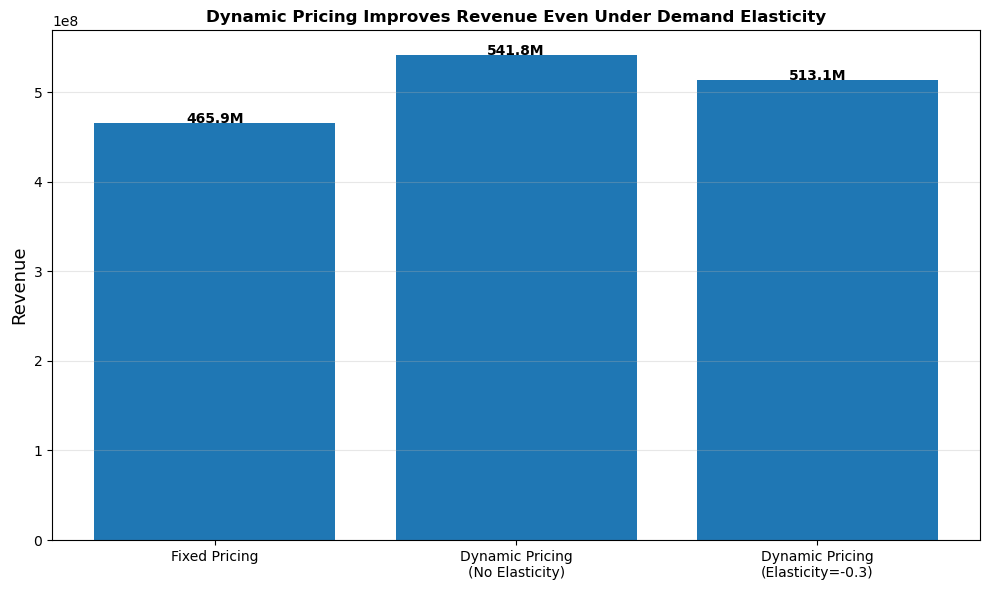

In [88]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    results["Scenario"],
    results["Revenue"]
)

for bar in bars:
    h = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        h,
        f"{h/1e6:.1f}M",
        ha="center",
        fontweight="bold"
    )

plt.title(
    "Dynamic Pricing Improves Revenue Even Under Demand Elasticity",
    fontweight="bold"
)

plt.ylabel(
    "Revenue",
    fontsize=13
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [91]:
import joblib

joblib.dump(rf2, "../outputs/demand_forecast_model.pkl")

['../outputs/demand_forecast_model.pkl']

In [92]:
master_clean.to_csv(
    "../outputs/final_pricing_dataset.csv",
    index=False
)

In [ ]:
results = pd.DataFrame({
    "Metric":[
        "Forecasting R2",
        "Revenue Gain (No Elasticity)",
        "Revenue Gain (Elasticity)"
    ],
    "Value":[
        0.9813,
        16,
        10
    ]
})

results

,Metric,Value
0,Forecasting R2,0.9813
1,Revenue Gain (No Elasticity),16.0000
2,Revenue Gain (Elasticity),10.0000


In [94]:
results.to_csv(
    "../outputs/final_results.csv",
    index=False
)